In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

## Data Cleaning and Processing ##

In [3]:
df = pd.read_csv('https://storage.googleapis.com/covid19-open-data/v3/epidemiology.csv')

In [4]:
df_states = df[df['location_key'].str.startswith('US_') & 
               (df['location_key'].str.len() == 5)]

In [5]:
# Pull policy/intervention data
df_policy = pd.read_csv('https://storage.googleapis.com/covid19-open-data/v3/oxford-government-response.csv')

# Filter to US states
df_policy_states = df_policy[df_policy['location_key'].str.startswith('US_') & 
                              (df_policy['location_key'].str.len() == 5)]

In [6]:
# Merge epidemiology and policy data on location_key and date
df_merged = pd.merge(df_states, df_policy_states, on=['location_key', 'date'], how='inner')

# exporting the merged dataset to a CSV file
df_merged.to_csv('covid19_epidemiology_policy_merged.csv', index=False)

In [7]:
# filling the na values with empty strings
df_merged_filled = df_merged.fillna('')

In [8]:
# printing all the columns in the merged dataset
pd.set_option('display.max_columns', None)
print(df_merged_filled.columns)

# Dropping columns that are not needed for analysis
columns_to_drop = ['fiscal_measures','public_information_campaigns','contact_tracing','stringency_index','international_support','public_transport_closing',
                   'international_travel_controls','cancel_public_events','debt_relief','new_tested','new_recovered','cumulative_tested','new_deceased']
df_final = df_merged_filled.drop(columns=columns_to_drop)


Index(['date', 'location_key', 'new_confirmed', 'new_deceased',
       'new_recovered', 'new_tested', 'cumulative_confirmed',
       'cumulative_deceased', 'cumulative_recovered', 'cumulative_tested',
       'school_closing', 'workplace_closing', 'cancel_public_events',
       'restrictions_on_gatherings', 'public_transport_closing',
       'stay_at_home_requirements', 'restrictions_on_internal_movement',
       'international_travel_controls', 'income_support', 'debt_relief',
       'fiscal_measures', 'international_support',
       'public_information_campaigns', 'testing_policy', 'contact_tracing',
       'emergency_investment_in_healthcare', 'investment_in_vaccines',
       'facial_coverings', 'vaccination_policy', 'stringency_index'],
      dtype='str')


In [9]:
# this block of code recodes the policy variables to binary (0 or 1) where 1 indicates the presence of a policy and 0 indicates its absence.
cols_to_recode = [
    'school_closing',
    'workplace_closing',
    'restrictions_on_gatherings',
    'stay_at_home_requirements',
    'facial_coverings',
    'vaccination_policy',
    'restrictions_on_internal_movement',
    'testing_policy'
]

for col in cols_to_recode:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')
    df_final[col] = (df_final[col].fillna(0) > 0).astype(int)


**Merging the data frames**


In [ ]:
df_cdc = pd.read_csv('your/file/path')

In [11]:
# Mapping the location_key from the Google dataset to the state names in the CDC dataset
# CDC Region mapping for US states
state_to_region = {
    # Region 1 - New England
    'US_CT': 1, 'US_MA': 1, 'US_ME': 1, 'US_NH': 1, 'US_RI': 1, 'US_VT': 1,
    # Region 2 - New York/New Jersey
    'US_NJ': 2, 'US_NY': 2,
    # Region 3 - Mid-Atlantic
    'US_DC': 3, 'US_DE': 3, 'US_MD': 3, 'US_PA': 3, 'US_VA': 3, 'US_WV': 3,
    # Region 4 - Southeast
    'US_AL': 4, 'US_FL': 4, 'US_GA': 4, 'US_KY': 4, 'US_MS': 4,
    'US_NC': 4, 'US_SC': 4, 'US_TN': 4,
    # Region 5 - Midwest
    'US_IL': 5, 'US_IN': 5, 'US_MI': 5, 'US_MN': 5, 'US_OH': 5, 'US_WI': 5,
    # Region 6 - South Central
    'US_AR': 6, 'US_LA': 6, 'US_NM': 6, 'US_OK': 6, 'US_TX': 6,
    # Region 7 - Central
    'US_IA': 7, 'US_KS': 7, 'US_MO': 7, 'US_NE': 7,
    # Region 8 - Mountain
    'US_CO': 8, 'US_MT': 8, 'US_ND': 8, 'US_SD': 8, 'US_UT': 8, 'US_WY': 8,
    # Region 9 - Pacific Southwest
    'US_AZ': 9, 'US_CA': 9, 'US_HI': 9, 'US_NV': 9,
    # Region 10 - Pacific Northwest
    'US_AK': 10, 'US_ID': 10, 'US_OR': 10, 'US_WA': 10,
}

# Validate no states are missing
all_states = {
    'US_AK', 'US_AL', 'US_AR', 'US_AZ', 'US_CA', 'US_CO', 'US_CT', 'US_DC',
    'US_DE', 'US_FL', 'US_GA', 'US_HI', 'US_IA', 'US_ID', 'US_IL', 'US_IN',
    'US_KS', 'US_KY', 'US_LA', 'US_MA', 'US_MD', 'US_ME', 'US_MI', 'US_MN',
    'US_MO', 'US_MS', 'US_MT', 'US_NC', 'US_ND', 'US_NE', 'US_NH', 'US_NJ',
    'US_NM', 'US_NV', 'US_NY', 'US_OH', 'US_OK', 'US_OR', 'US_PA', 'US_RI',
    'US_SC', 'US_SD', 'US_TN', 'US_TX', 'US_UT', 'US_VA', 'US_VT', 'US_WA',
    'US_WI', 'US_WV', 'US_WY'
}

missing = all_states - set(state_to_region.keys())
if missing:
    print(f"WARNING: Missing states in mapping: {missing}")
else:
    print(f"Mapping complete: {len(state_to_region)} states/territories mapped across {len(set(state_to_region.values()))} regions")

Mapping complete: 51 states/territories mapped across 10 regions


In [12]:
# Create date column from year and month
df_cdc['date'] = pd.to_datetime(df_cdc[['year', 'month']].assign(day=1))

# Create region column (extract number from jurisdiction_residence)
df_cdc['region'] = df_cdc['jurisdiction_residence'].str.extract(r'(\d+)').astype(int)

# Split into sex and race data
df_cdc_sex = df_cdc[df_cdc['group'] == 'Sex'].copy()
df_cdc_race = df_cdc[df_cdc['group'] == 'Race and Age'].copy()

print(f"Sex data shape: {df_cdc_sex.shape}")
print(f"Race data shape: {df_cdc_race.shape}")
print(f"\nSex data columns: {df_cdc_sex.columns.tolist()}")
print(f"\nFirst few rows of sex data:")
print(df_cdc_sex[['region', 'date', 'subgroup1', 'COVID_deaths', 'crude_COVID_rate']].head())
print(f"\nFirst few rows of race data:")
print(df_cdc_race[['region', 'date', 'subgroup1', 'subgroup2', 'COVID_deaths', 'crude_COVID_rate']].head())

Sex data shape: (720, 10)
Race data shape: (22680, 10)

Sex data columns: ['jurisdiction_residence', 'year', 'month', 'group', 'subgroup1', 'subgroup2', 'COVID_deaths', 'crude_COVID_rate', 'date', 'region']

First few rows of sex data:
     region       date subgroup1 COVID_deaths  crude_COVID_rate
0         1 2023-01-01    Female          431               5.6
1         1 2023-01-01      Male          413               5.6
65        1 2023-02-01    Female          261               3.4
66        1 2023-02-01      Male          231               3.1
130       1 2023-03-01    Female          154               2.0

First few rows of race data:
   region       date subgroup1    subgroup2 COVID_deaths  crude_COVID_rate
2       1 2023-01-01  Hispanic    0-4 years            0               0.0
3       1 2023-01-01  Hispanic  12-17 years            0               0.0
4       1 2023-01-01  Hispanic  18-29 years          NaN               NaN
5       1 2023-01-01  Hispanic  30-39 years       

In [13]:
# Add region to policy data
df_final['region'] = df_final['location_key'].map(state_to_region)

# Create month-level date for merging
df_final['date_month'] = pd.to_datetime(df_final['date']).dt.to_period('M').dt.to_timestamp()



In [14]:
# Policy columns that are already binary (0/1)
policy_columns = ['school_closing', 'workplace_closing', 'restrictions_on_gatherings', 
                  'stay_at_home_requirements', 'facial_coverings', 'vaccination_policy',
                  'restrictions_on_internal_movement', 'testing_policy']

for col in policy_columns:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0).astype(int)

# Cumulative columns
cumulative_columns = ['cumulative_confirmed', 'cumulative_deceased', 'cumulative_recovered']
for col in cumulative_columns:
    if col in df_final.columns:
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)

# Aggregate to region-month level
df_final_region = df_final.groupby(['region', 'date_month']).agg({
    **{col: 'mean' for col in policy_columns},
    **{col: 'sum' for col in cumulative_columns}
}).reset_index()

# Convert policy means back to binary (0/1) based on majority (>0.5)
for col in policy_columns:
    df_final_region[col] = (df_final_region[col] > 0.5).astype(int)

print(f"Aggregated policy shape: {df_final_region.shape}")
print(f"Regions: {df_final_region['region'].nunique()}")
print(f"Months: {df_final_region['date_month'].nunique()}")
print(f"Expected rows: 10 regions × 31 months = 310")
print(f"Actual rows: {len(df_final_region)}")
print(f"\nFirst few rows:")
print(df_final_region.head())

Aggregated policy shape: (310, 13)
Regions: 10
Months: 31
Expected rows: 10 regions × 31 months = 310
Actual rows: 310

First few rows:
   region date_month  school_closing  workplace_closing  \
0       1 2020-01-01               0                  0   
1       1 2020-02-01               0                  0   
2       1 2020-03-01               1                  1   
3       1 2020-04-01               1                  1   
4       1 2020-05-01               1                  1   

   restrictions_on_gatherings  stay_at_home_requirements  facial_coverings  \
0                           0                          0                 0   
1                           0                          0                 0   
2                           1                          0                 0   
3                           1                          1                 1   
4                           1                          1                 1   

   vaccination_policy  restrictions_on_i

In [15]:
# Filter policy data to overlap period (01-01-2021 to 01-07-2022)
overlap_start = pd.Timestamp('2021-01-01')
overlap_end = pd.Timestamp('2022-07-01')
df_final_region_overlap = df_final_region[
    (df_final_region['date_month'] >= overlap_start) & 
    (df_final_region['date_month'] <= overlap_end)
].copy()

# Filter CDC sex data to same period
df_cdc_sex_overlap = df_cdc_sex[
    (df_cdc_sex['date'] >= overlap_start) & 
    (df_cdc_sex['date'] <= overlap_end)
].copy()

# Expand policy data for sex categories
sex_categories = df_cdc_sex_overlap['subgroup1'].unique()

df_policy_sex_expanded = pd.concat([df_final_region_overlap.assign(subgroup1=sex) for sex in sex_categories], ignore_index=True)

# Merge with CDC sex data
df_merged_sex = pd.merge(
    df_policy_sex_expanded,
    df_cdc_sex_overlap[['region', 'date', 'subgroup1', 'COVID_deaths', 'crude_COVID_rate']],
    left_on=['date_month', 'region', 'subgroup1'],
    right_on=['date', 'region', 'subgroup1'],
    how='inner'
)


In [16]:
# Filter CDC race data to overlap period
df_cdc_race_overlap = df_cdc_race[
    (df_cdc_race['date'] >= overlap_start) & 
    (df_cdc_race['date'] <= overlap_end)
].copy()

# Get unique race categories
race_categories = df_cdc_race_overlap['subgroup1'].unique()
print(f"\nRace categories ({len(race_categories)}):")
for race in race_categories:
    print(f"  - {race}")

# Expand policy data for race categories
df_policy_race_expanded = pd.concat([df_final_region_overlap.assign(subgroup1=race) for race in race_categories], ignore_index=True)
# Merge with CDC race data
df_merged_race = pd.merge(
    df_policy_race_expanded,
    df_cdc_race_overlap[['region', 'date', 'subgroup1', 'subgroup2', 'COVID_deaths', 'crude_COVID_rate']],
    left_on=['date_month', 'region', 'subgroup1'],
    right_on=['date', 'region', 'subgroup1'],
    how='inner'
)




Race categories (7):
  - Hispanic
  - Non-Hispanic American Indian or Alaska Native
  - Non-Hispanic Asian
  - Non-Hispanic Asian, Native Hawaiian or Other Pacific Islander
  - Non-Hispanic Black
  - Non-Hispanic Native Hawaiian or Other Pacific Islander
  - Non-Hispanic White


For the purposes of analysis I created two data sets one with respect to sex and the other with respect to race.

In [17]:
df_merged_sex = pd.merge(df_final, df_cdc_sex,
                         left_on=['date_month', 'region'],
                         right_on=['date', 'region'],
                         how='left')

df_merged_race = pd.merge(df_final, df_cdc_race,
                          left_on=['date_month', 'region'],
                          right_on=['date', 'region'],
                          how='left')

print(df_merged_sex.shape)
print(df_merged_race.shape)

(74870, 28)
(1821483, 28)


## Machine Learning Section

In [18]:
from sklearn import tree, metrics
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

**Random Forest vs Decision Tree**

In [19]:
# Random Forest vs DecisionTree
# Policy columns
policy_cols = [
    'school_closing', 'workplace_closing', 'restrictions_on_gatherings',
    'stay_at_home_requirements', 'facial_coverings', 'vaccination_policy',
    'restrictions_on_internal_movement', 'testing_policy'
]

# Prepare data
df_model = df_merged_race.copy()
df_model['COVID_deaths'] = pd.to_numeric(df_model['COVID_deaths'], errors='coerce')
df_model['subgroup1_enc'] = df_model['subgroup1'].astype('category').cat.codes
df_model['subgroup2_enc'] = df_model['subgroup2'].astype('category').cat.codes

# Features 
feature_cols = policy_cols + ['region', 'subgroup1_enc', 'subgroup2_enc']
X = df_model[feature_cols].fillna(0)
y = pd.to_numeric(df_model['COVID_deaths'], errors='coerce')

# Clean data
valid_idx = y.notna()
X, y = X[valid_idx], y[valid_idx]

print(f"Dataset: {X.shape}, Deaths: {y.min():.0f}-{y.max():.0f}, Zeros: {(y==0).sum()} ({((y==0).sum()/len(y))*100:.1f}%)")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
dt = DecisionTreeRegressor(max_depth=5, min_samples_split=100, min_samples_leaf=50, random_state=42)
rf = RandomForestRegressor(n_estimators=100, max_depth=6, min_samples_split=100, 
                           min_samples_leaf=50, random_state=42, n_jobs=-1)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Results
print("\n" * 50)
print("DECISION TREE")
print(f"R²: {r2_score(y_test, dt.predict(X_test)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, dt.predict(X_test)):.2f}")

print("\n" * 50)
print("RANDOM FOREST")
print(f"R²: {r2_score(y_test, rf.predict(X_test)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, rf.predict(X_test)):.2f}")

# Cross-validation
cv_dt = cross_val_score(dt, X, y, cv=5, scoring='r2')
cv_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"\nCV Decision Tree: {cv_dt.mean():.4f} (+/- {cv_dt.std():.4f})")
print(f"CV Random Forest: {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")

# Feature importance
importance_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print("\nTop 5 Features:")
print(importance_df.head(5).to_string(index=False))

Dataset: (1239825, 11), Deaths: 0-995, Zeros: 782138 (63.1%)



















































DECISION TREE
R²: 0.5127
MAE: 34.18



















































RANDOM FOREST
R²: 0.5484
MAE: 32.35

CV Decision Tree: 0.5012 (+/- 0.0195)
CV Random Forest: 0.5347 (+/- 0.0199)

Top 5 Features:
          feature  importance
    subgroup1_enc    0.491925
    subgroup2_enc    0.366594
           region    0.128244
workplace_closing    0.010015
   school_closing    0.003120


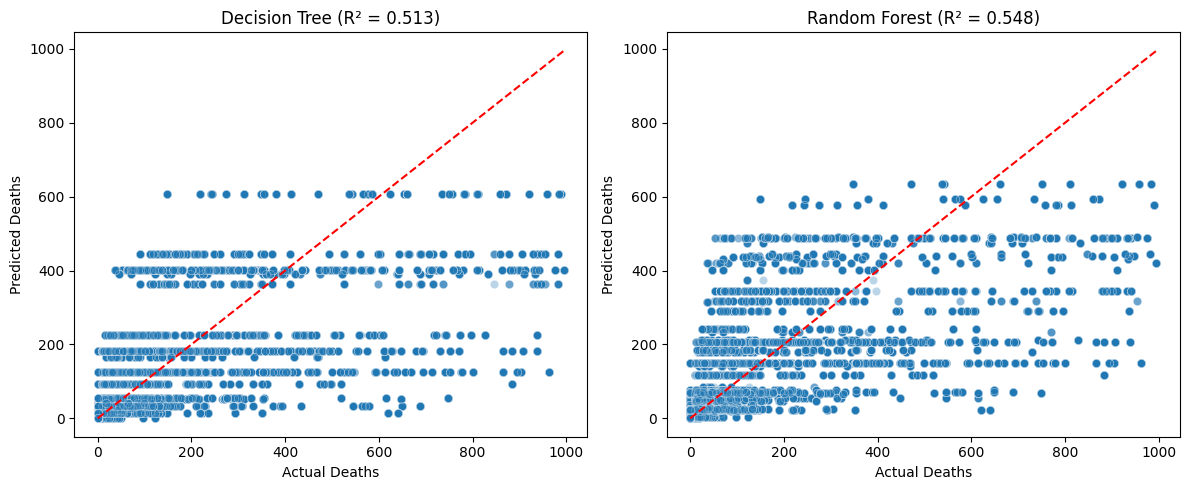

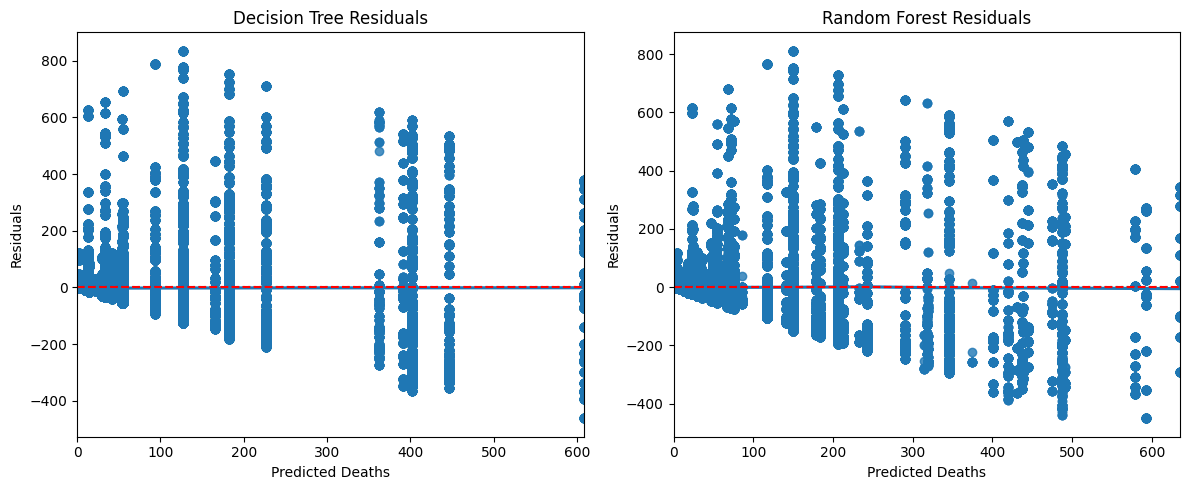

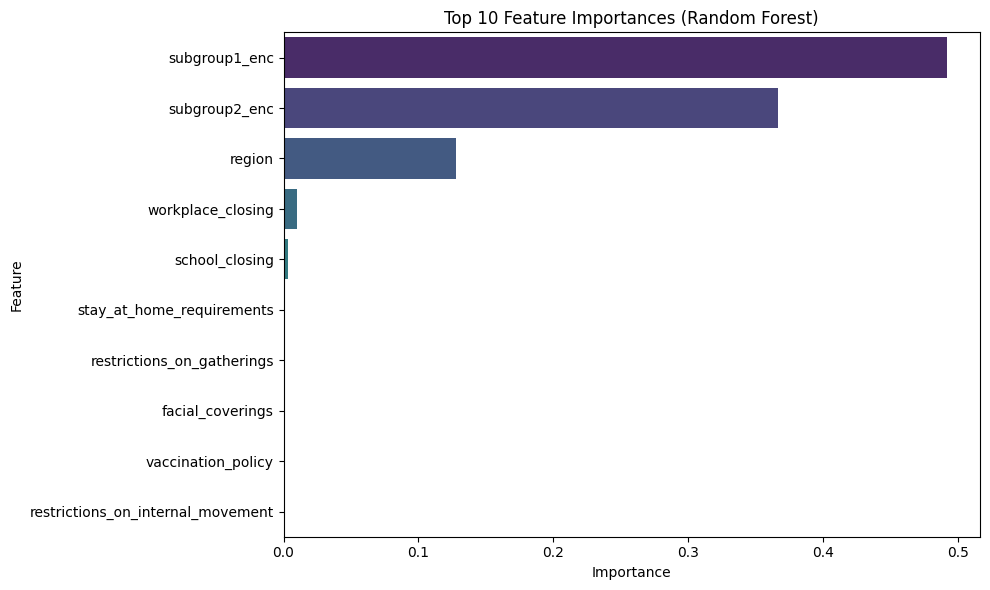

In [20]:
# Predictions
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Predictions scatter plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.3, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title(f'Decision Tree (R² = {r2_score(y_test, y_pred_dt):.3f})')
axes[0].set_xlabel('Actual Deaths')
axes[0].set_ylabel('Predicted Deaths')

sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.3, ax=axes[1])
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title(f'Random Forest (R² = {r2_score(y_test, y_pred_rf):.3f})')
axes[1].set_xlabel('Actual Deaths')
axes[1].set_ylabel('Predicted Deaths')

plt.tight_layout()
plt.show()

# Residual plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.residplot(x=y_pred_dt, y=y_test, lowess=True, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Decision Tree Residuals')
axes[0].set_xlabel('Predicted Deaths')
axes[0].set_ylabel('Residuals')

sns.residplot(x=y_pred_rf, y=y_test, lowess=True, ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Random Forest Residuals')
axes[1].set_xlabel('Predicted Deaths')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

# Feature importance bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Decision Tree**

In [21]:
def train_decision_tree(race):
    df_race = df_merged_race[df_merged_race['subgroup1'] == race].copy()
    df_race['COVID_deaths'] = pd.to_numeric(df_race['COVID_deaths'], errors='coerce')
    df_race['subgroup2_enc'] = df_race['subgroup2'].astype('category').cat.codes
    
    feature_cols = policy_cols + ['region', 'subgroup2_enc']
    X = df_race[feature_cols].fillna(0)
    y = df_race['COVID_deaths'].dropna()
    X = X.loc[y.index]
    
    if len(X) < 50:
        return {'race': race, 'samples': len(X), 'skipped': True}
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Decision Tree
    dt = DecisionTreeRegressor(max_depth=5, min_samples_split=100, 
                               min_samples_leaf=50, random_state=42)
    dt.fit(X_train, y_train)
    
    y_pred = dt.predict(X_test)
    
    return {
        'race': race,
        'samples': len(X),
        'r2': r2_score(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'feature_importance': dt.feature_importances_,  # ADD THIS LINE
        'model': dt
    }

# Re-run the training
dt_results = {race: train_decision_tree(race) for race in race_categories}

# Recreate the summary dataframe
dt_summary_df = pd.DataFrame([{
    'Race': r['race'], 
    'Samples': r['samples'], 
    'R²': r.get('r2'), 
    'MAE': r.get('mae')
} for r in dt_results.values()])

print(dt_summary_df.to_string(index=False))

                                                         Race  Samples       R²       MAE
                                                     Hispanic   177470 0.440543 44.980305
                Non-Hispanic American Indian or Alaska Native   174865 0.580608  2.647297
                                           Non-Hispanic Asian   171031 0.528015  7.756062
Non-Hispanic Asian, Native Hawaiian or Other Pacific Islander   168346 0.512866  8.496360
                                           Non-Hispanic Black   174583 0.417243 47.190700
       Non-Hispanic Native Hawaiian or Other Pacific Islander   199698 0.780684  0.188713
                                           Non-Hispanic White   173832 0.564315 91.971204


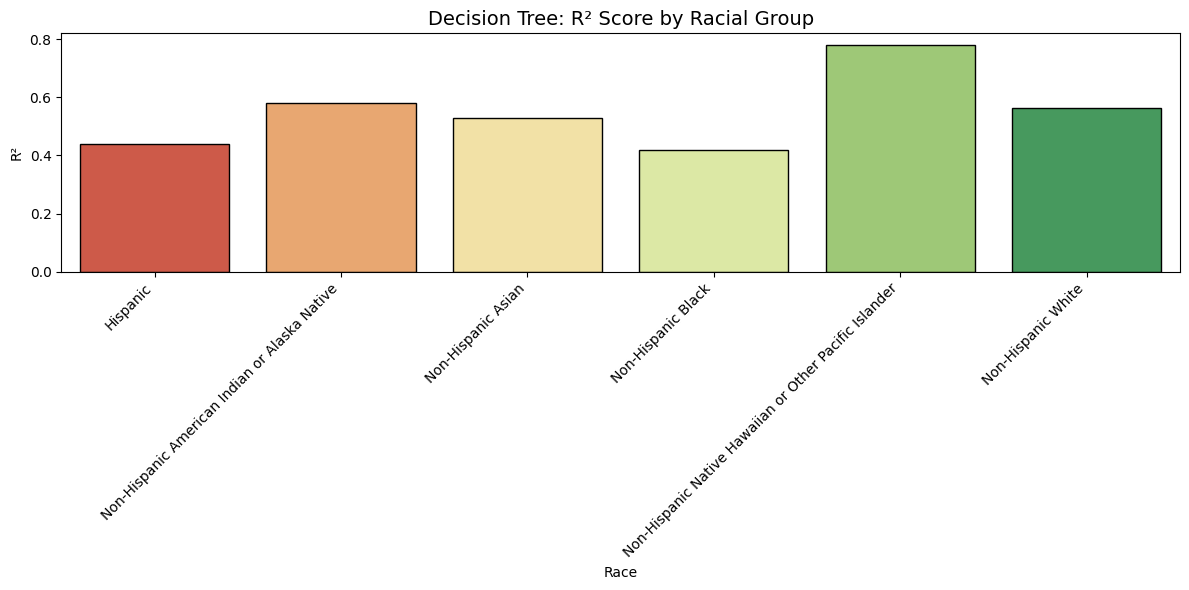

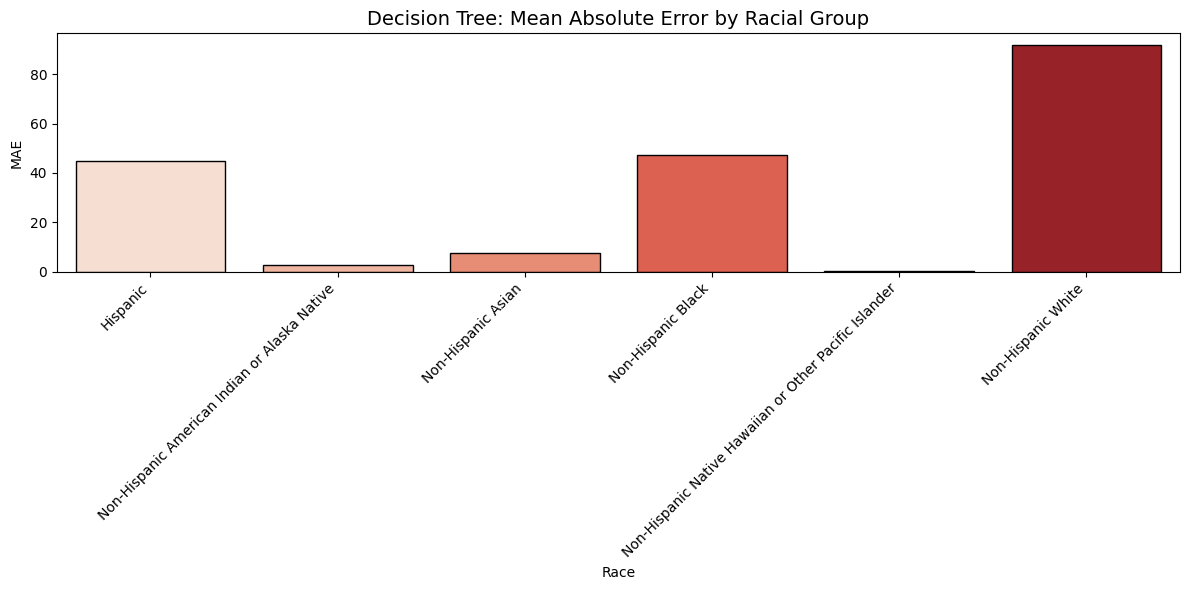

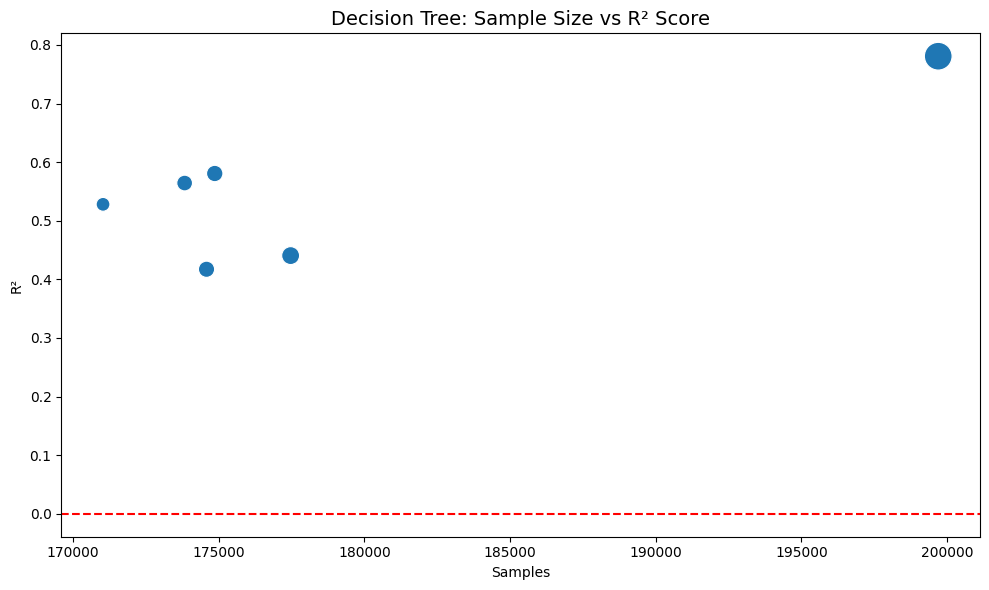

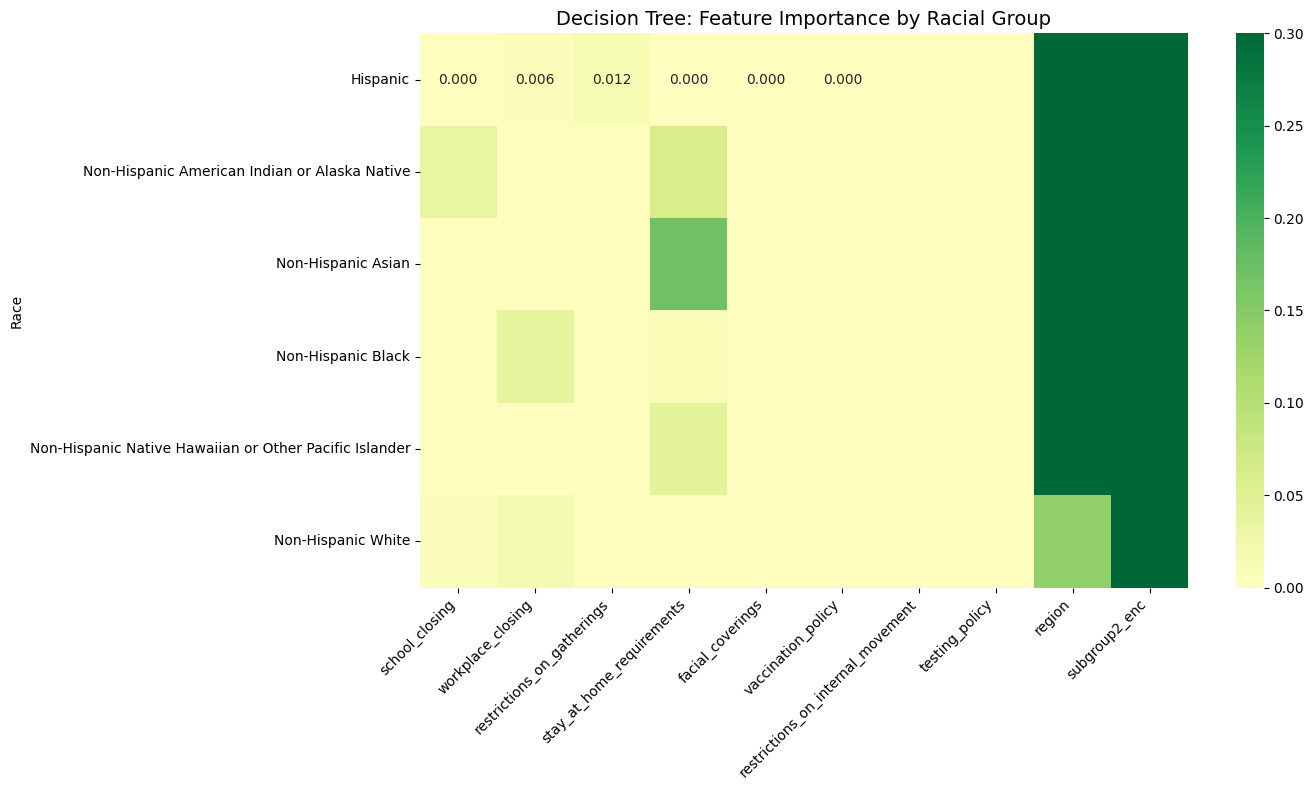

In [22]:
# Filter out rows with NaN R² values and exclude the combined column
dt_valid_results = dt_summary_df[
    (dt_summary_df['R²'].notna()) & 
    (dt_summary_df['Race'] != 'Non-Hispanic Asian, Native Hawaiian or Other Pacific Islander')
].copy()

# R² Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=dt_valid_results, x='Race', y='R²', palette='RdYlGn', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Decision Tree: R² Score by Racial Group', fontsize=14)
plt.tight_layout()
plt.show()

# MAE Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=dt_valid_results, x='Race', y='MAE', palette='Reds', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Decision Tree: Mean Absolute Error by Racial Group', fontsize=14)
plt.tight_layout()
plt.show()

# Samples vs R² Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dt_valid_results, x='Samples', y='R²', size='Samples', 
                sizes=(100, 400), legend=False, palette='viridis')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Decision Tree: Sample Size vs R² Score', fontsize=14)
plt.tight_layout()
plt.show()

# Heatmap
all_features = policy_cols + ['region', 'subgroup2_enc']
heatmap_data = pd.DataFrame([dt_results[r]['feature_importance'] for r in dt_valid_results['Race']], 
                            index=dt_valid_results['Race'], columns=all_features)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0, vmin=0, vmax=0.3)
plt.title('Decision Tree: Feature Importance by Racial Group', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Random Forest**

In [23]:
# Policy columns
policy_cols = [
    'school_closing', 'workplace_closing', 'restrictions_on_gatherings',
    'stay_at_home_requirements', 'facial_coverings', 'vaccination_policy',
    'restrictions_on_internal_movement', 'testing_policy'
]

# Race categories
race_categories = df_merged_race['subgroup1'].unique()
race_categories = [race for race in race_categories if race != 'Non-Hispanic Asian, Native Hawaiian or Other Pacific Islander']

# 
def train_model(race):
    df_race = df_merged_race[df_merged_race['subgroup1'] == race].copy()
    df_race['COVID_deaths'] = pd.to_numeric(df_race['COVID_deaths'], errors='coerce')
    df_race['subgroup2_enc'] = df_race['subgroup2'].astype('category').cat.codes
    
    feature_cols = policy_cols + ['region', 'subgroup2_enc']
    X = df_race[feature_cols].fillna(0)
    y = df_race['COVID_deaths'].dropna()
    X = X.loc[y.index]
    
    if len(X) < 50:
        return {'race': race, 'samples': len(X), 'skipped': True}
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf = RandomForestRegressor(n_estimators=100, max_depth=6, 
                               min_samples_split=50, min_samples_leaf=25, 
                               random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    
    return {
        'race': race,
        'samples': len(X),
        'r2': r2_score(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'feature_importance': rf.feature_importances_,
        'model': rf
    }

# Train models
results = {race: train_model(race) for race in race_categories}

# summary dataframe
summary_df = pd.DataFrame([{
    'Race': r['race'], 
    'Samples': r['samples'], 
    'R²': r.get('r2'), 
    'MAE': r.get('mae')
} for r in results.values()])

print(summary_df.to_string(index=False))

                                                  Race  Samples       R²       MAE
                                                   NaN        0      NaN       NaN
                                              Hispanic   177470 0.470855 43.136708
         Non-Hispanic American Indian or Alaska Native   174865 0.647037  2.273067
                                    Non-Hispanic Asian   171031 0.531950  7.438559
                                    Non-Hispanic Black   174583 0.462759 44.685698
Non-Hispanic Native Hawaiian or Other Pacific Islander   199698 0.788195  0.181681
                                    Non-Hispanic White   173832 0.596947 88.176809


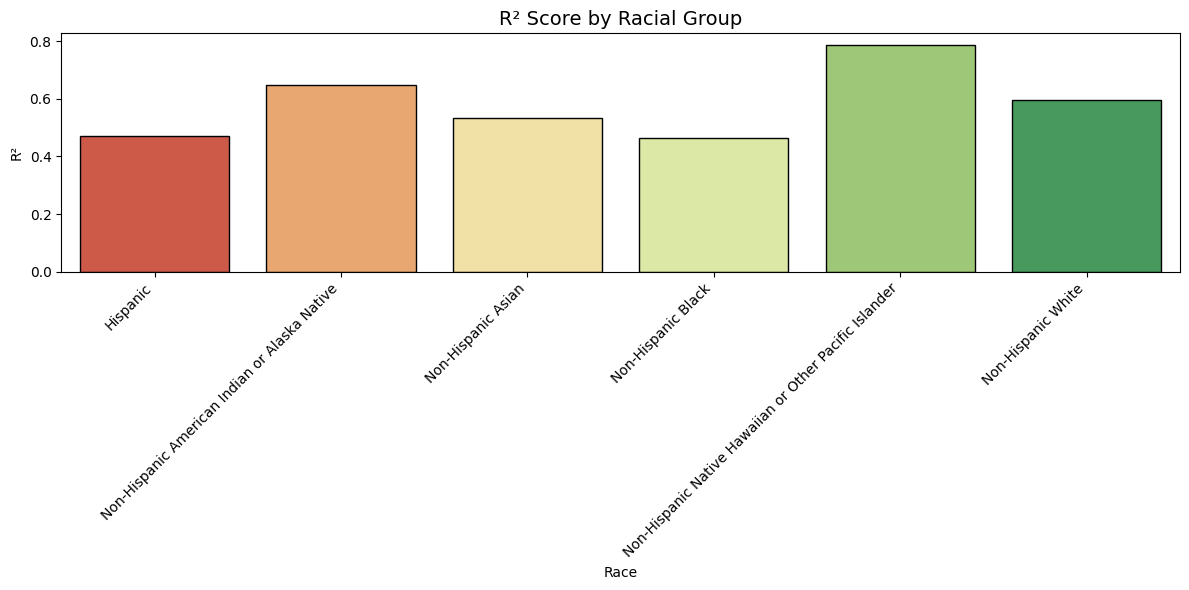

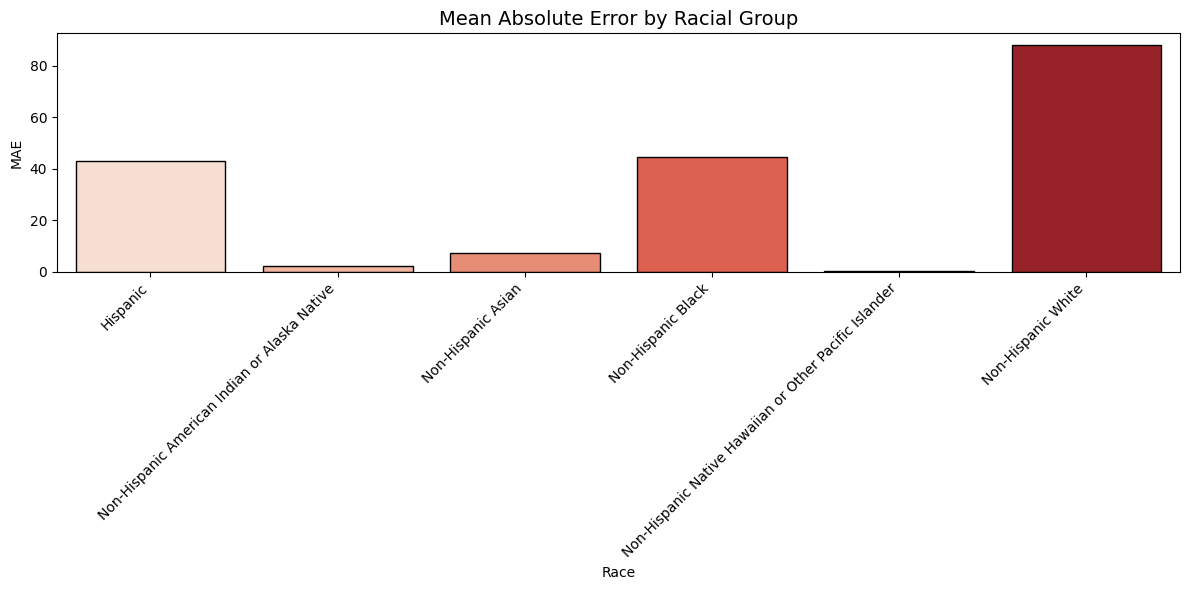

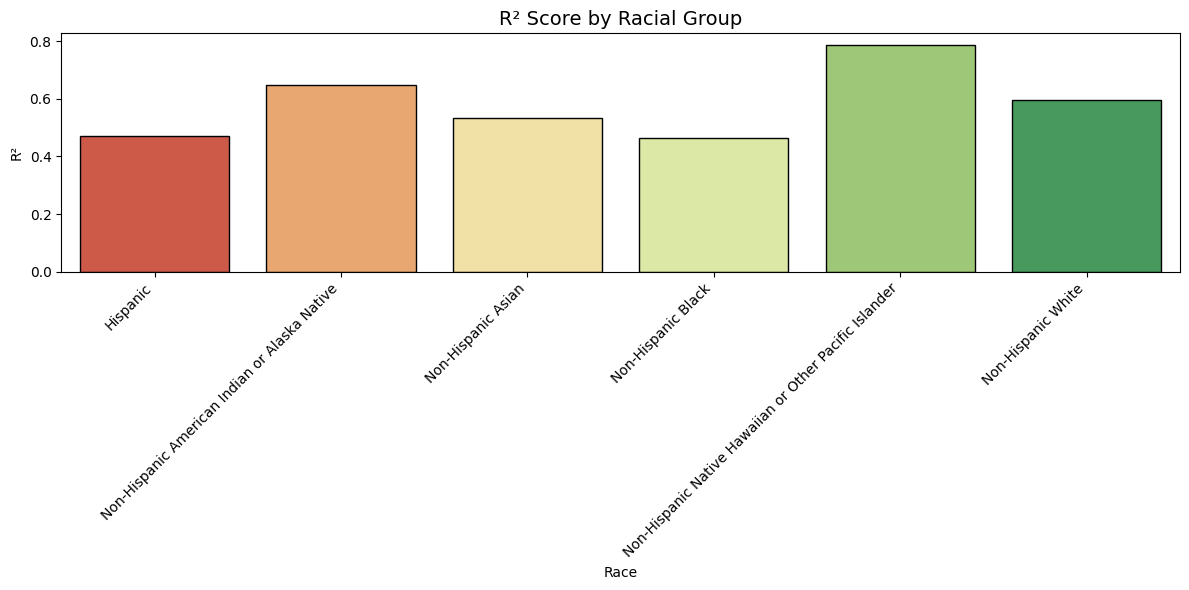

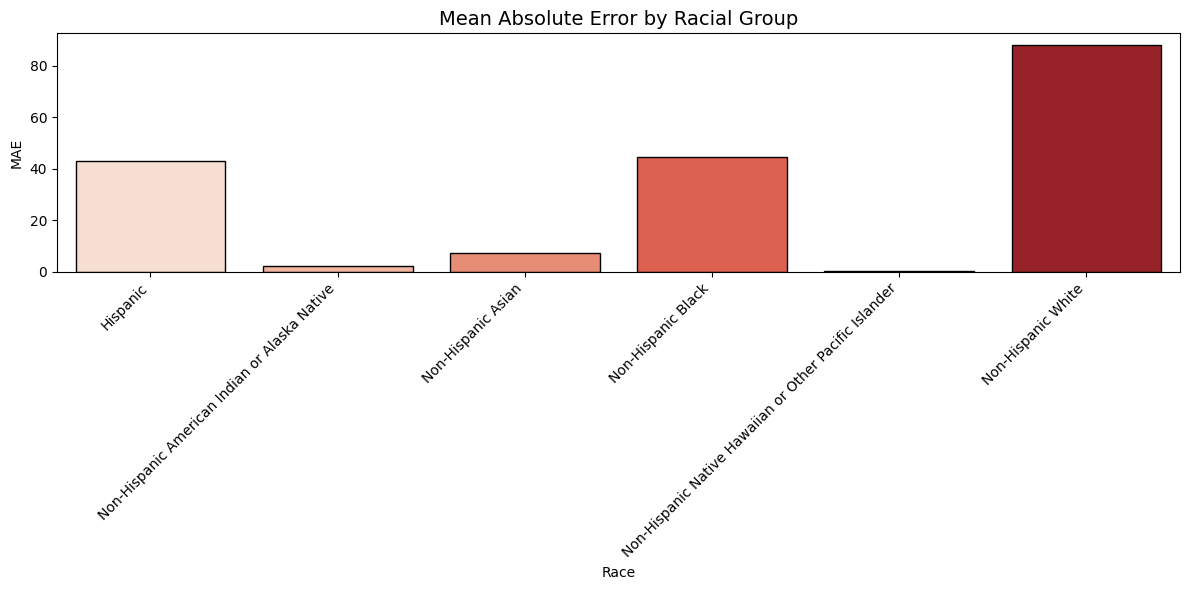

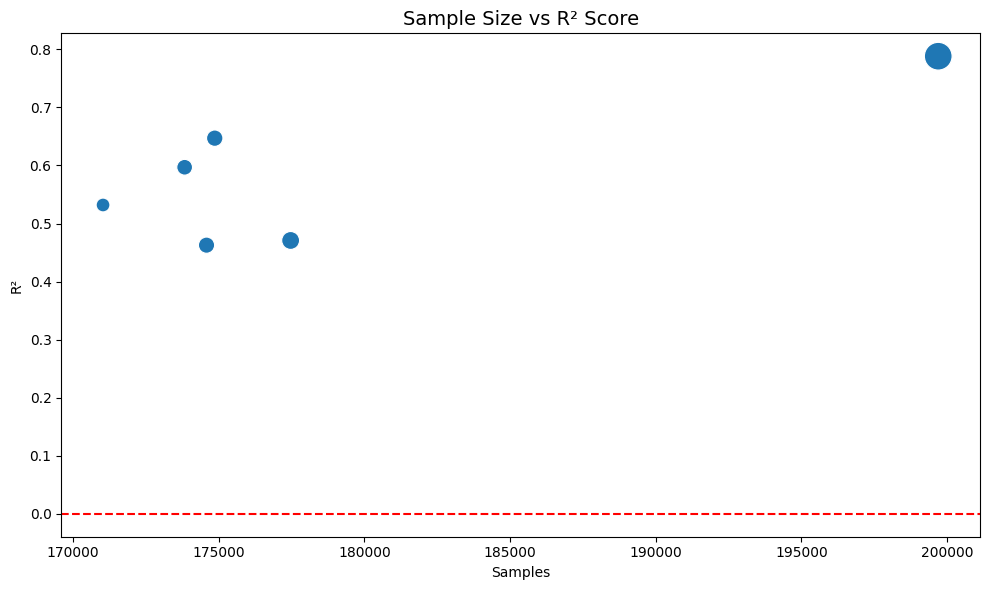

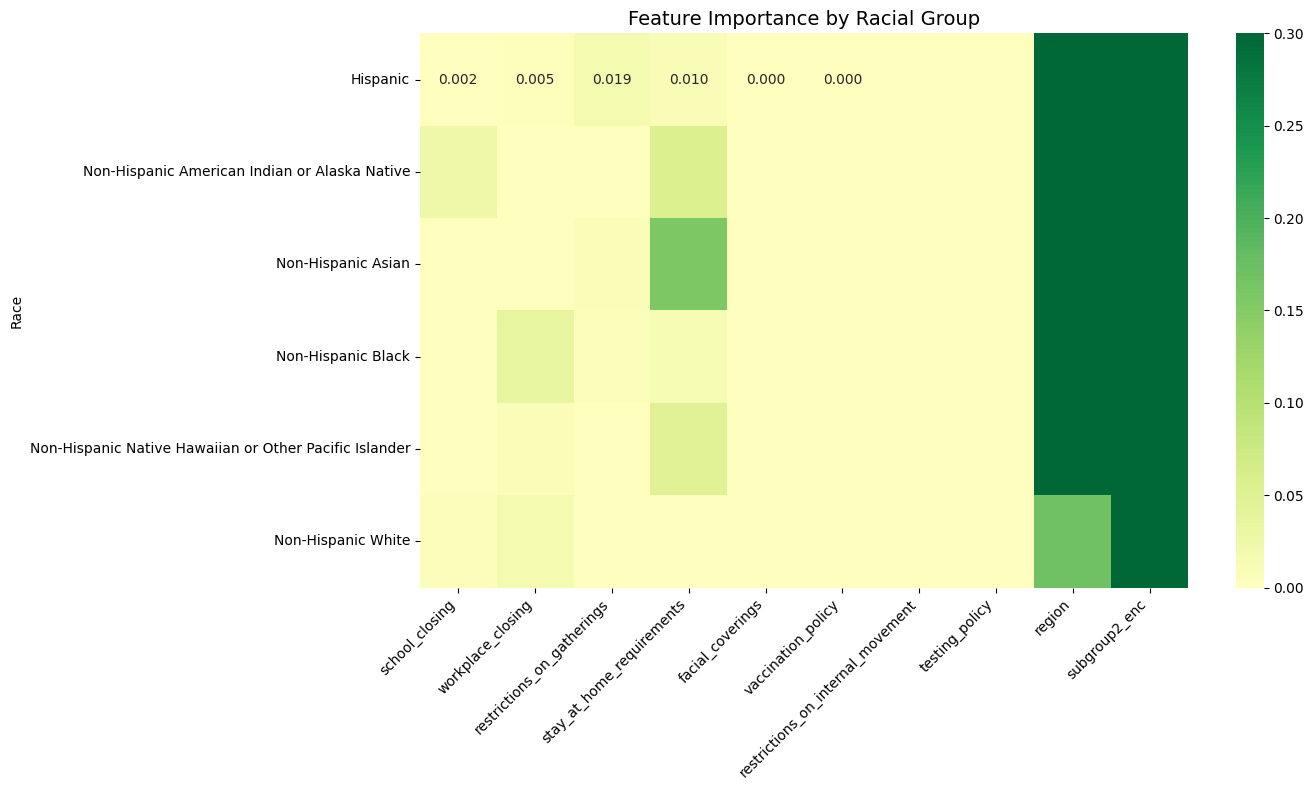

In [24]:
valid_results = summary_df[
    (summary_df['R²'].notna()) & 
    (summary_df['Race'] != 'Non-Hispanic Asian, Native Hawaiian or Other Pacific Islander')
].copy()

# R² Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=valid_results, x='Race', y='R²', palette='RdYlGn', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('R² Score by Racial Group', fontsize=14)
plt.tight_layout()
plt.show()

# MAE Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=valid_results, x='Race', y='MAE', palette='Reds', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Mean Absolute Error by Racial Group', fontsize=14)
plt.tight_layout()
plt.show()

# R² Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=valid_results, x='Race', y='R²', palette='RdYlGn', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('R² Score by Racial Group', fontsize=14)
plt.tight_layout()
plt.show()

# 2. MAE Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=valid_results, x='Race', y='MAE', palette='Reds', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Mean Absolute Error by Racial Group', fontsize=14)
plt.tight_layout()
plt.show()

# Samples vs R² Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(data=valid_results, x='Samples', y='R²', size='Samples', 
                sizes=(100, 400), legend=False, palette='viridis')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Sample Size vs R² Score', fontsize=14)
plt.tight_layout()
plt.show()

# Heatmap
all_features = policy_cols + ['region', 'subgroup2_enc']
heatmap_data = pd.DataFrame([results[r]['feature_importance'] for r in valid_results['Race']], 
                            index=valid_results['Race'], columns=all_features)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0, vmin=0, vmax=0.3)
plt.title('Feature Importance by Racial Group', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Statistical Significance**

In [25]:
from sklearn.dummy import DummyRegressor
from scipy import stats

# Create and train dummy model
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

# Get errors
rf_errors = np.abs(y_test - rf.predict(X_test))
dummy_errors = np.abs(y_test - dummy.predict(X_test))

# Medians
rf_median = np.median(rf_errors)
dummy_median = np.median(dummy_errors)

# Wilcoxon test
statistic, p_value = stats.wilcoxon(rf_errors, dummy_errors, alternative='less')

print(f"Random Forest MAE (median): {rf_median:.2f}")
print(f"Dummy Model MAE (median): {dummy_median:.2f}")
print(f"Improvement: {((dummy_median - rf_median) / dummy_median * 100):.1f}%")
print(f"Wilcoxon p-value: {p_value:.6f}")
print(f"\nStatistically significant? {'YES' if p_value < 0.05 else 'NO'}")

Random Forest MAE (median): 2.13
Dummy Model MAE (median): 44.31
Improvement: 95.2%
Wilcoxon p-value: 0.000000

Statistically significant? YES


In [26]:

# Create and train dummy model
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)

# Get errors for Decision Tree
dt_errors = np.abs(y_test - dt.predict(X_test))
dummy_errors = np.abs(y_test - dummy.predict(X_test))

# Medians
dt_median = np.median(dt_errors)
dummy_median = np.median(dummy_errors)

# Wilcoxon test
statistic, p_value = stats.wilcoxon(dt_errors, dummy_errors, alternative='less')


print("DECISION TREE SIGNIFICANCE TEST")
print(f"Decision Tree MAE (median): {dt_median:.2f}")
print(f"Dummy Model MAE (median): {dummy_median:.2f}")
print(f"Improvement: {((dummy_median - dt_median) / dummy_median * 100):.1f}%")
print(f"Wilcoxon p-value: {p_value:.6f}")
print(f"\nStatistically significant? {'YES' if p_value < 0.05 else 'NO'}")

DECISION TREE SIGNIFICANCE TEST
Decision Tree MAE (median): 1.89
Dummy Model MAE (median): 44.31
Improvement: 95.7%
Wilcoxon p-value: 0.000000

Statistically significant? YES


**Descriptive Statistics**

In [27]:
print("SEX DATA")
# Convert COVID_deaths to numeric
df_merged_sex['COVID_deaths'] = pd.to_numeric(df_merged_sex['COVID_deaths'], errors='coerce')

# Basic info
print(f"Shape: {df_merged_sex.shape}")
print(f"Rows: {df_merged_sex.shape[0]:,}, Columns: {df_merged_sex.shape[1]}")
print(f"\nDate range: {df_merged_sex['date_month'].min()} to {df_merged_sex['date_month'].max()}")

# Deaths by sex
print("\n--- COVID Deaths by Sex ---")
print(df_merged_sex.groupby('subgroup1')['COVID_deaths'].agg(['count', 'mean', 'std', 'min', 'max']))

# Policy adoption rates
policy_cols = ['school_closing', 'workplace_closing', 'restrictions_on_gatherings',
               'stay_at_home_requirements', 'facial_coverings', 'vaccination_policy']
print("\n--- Policy Adoption Rates (0-1) ---")
print(df_merged_sex[policy_cols].mean().sort_values(ascending=False))

SEX DATA
Shape: (74870, 28)
Rows: 74,870, Columns: 28

Date range: 2020-01-01 00:00:00 to 2022-07-01 00:00:00

--- COVID Deaths by Sex ---
           count        mean         std   min    max
subgroup1                                            
Female     16330  464.573546  273.116683  62.0  982.0
Male       14011  476.198844  270.273715  60.0  975.0

--- Policy Adoption Rates (0-1) ---
facial_coverings              0.943689
school_closing                0.791452
vaccination_policy            0.775892
workplace_closing             0.526205
stay_at_home_requirements     0.406558
restrictions_on_gatherings    0.401429
dtype: float64


In [28]:
print("RACE DATA")

# Convert COVID_deaths to numeric
df_merged_race['COVID_deaths'] = pd.to_numeric(df_merged_race['COVID_deaths'], errors='coerce')

# Basic info
print(f"Shape: {df_merged_race.shape}")
print(f"Rows: {df_merged_race.shape[0]:,}, Columns: {df_merged_race.shape[1]}")
print(f"\nDate range: {df_merged_race['date_month'].min()} to {df_merged_race['date_month'].max()}")

# Unique races
print(f"\nUnique race groups: {df_merged_race['subgroup1'].nunique()}")
print(df_merged_race['subgroup1'].unique())

# Deaths by race
print("\n--- COVID Deaths by Race ---")
print(df_merged_race.groupby('subgroup1')['COVID_deaths'].agg(['count', 'mean', 'std', 'min', 'max']))

# Deaths by region
print("\n--- COVID Deaths by CDC Region ---")
print(df_merged_race.groupby('region')['COVID_deaths'].agg(['sum', 'mean', 'count']))

RACE DATA
Shape: (1821483, 28)
Rows: 1,821,483, Columns: 28

Date range: 2020-01-01 00:00:00 to 2022-07-01 00:00:00

Unique race groups: 7
<StringArray>
[                                                            nan,
                                                      'Hispanic',
                 'Non-Hispanic American Indian or Alaska Native',
                                            'Non-Hispanic Asian',
 'Non-Hispanic Asian, Native Hawaiian or Other Pacific Islander',
                                            'Non-Hispanic Black',
        'Non-Hispanic Native Hawaiian or Other Pacific Islander',
                                            'Non-Hispanic White']
Length: 8, dtype: str

--- COVID Deaths by Race ---
                                                     count        mean  \
subgroup1                                                                
Hispanic                                            177470   62.206153   
Non-Hispanic American Indian or Alaska Native